# Analyse SaaS : revenu, churn et usage produit

Ce notebook répond aux cinq points du cas technique : exploration des données, MRR, churn, usage produit et recommandations.

Dataset : RavenStack SaaS Subscription & Churn Analytics Dataset, créé par River @ Rivalytics.

L'objectif est surtout d'obtenir des indicateurs simples et interprétables. Les limites du dataset sont signalées lorsqu'elles peuvent influencer les résultats.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)  # affiche toutes les colonnes des DataFrames

## 1. Exploration des données

### 1.1 Chargement des tables

Le dataset contient cinq fichiers : comptes, abonnements, usage produit, événements de churn et tickets support.


In [2]:
comptes = pd.read_csv("ravenstack_accounts.csv")
abonnements = pd.read_csv("ravenstack_subscriptions.csv")
usage = pd.read_csv("ravenstack_feature_usage.csv")
churn = pd.read_csv("ravenstack_churn_events.csv")
support = pd.read_csv("ravenstack_support_tickets.csv")

print("Comptes clients :", comptes.shape)
print("Abonnements :", abonnements.shape)
print("Utilisation des fonctionnalités :", usage.shape)
print("Événements de churn :", churn.shape)
print("Tickets support :", support.shape)

Comptes clients : (500, 10)
Abonnements : (5000, 14)
Utilisation des fonctionnalités : (25000, 8)
Événements de churn : (600, 9)
Tickets support : (2000, 9)


In [3]:
tables = {
    "Comptes clients": comptes,
    "Abonnements": abonnements,
    "Utilisation des fonctionnalités": usage,
    "Événements de churn": churn,
    "Tickets support": support
}

for nom, df in tables.items():
    print(f"\n--- {nom} ---")
    display(df.head())


--- Comptes clients ---


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



--- Abonnements ---


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



--- Utilisation des fonctionnalités ---


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



--- Événements de churn ---


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive



--- Tickets support ---


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


### 1.2 Description rapide des tables

- `accounts` : une ligne par compte client. On y trouve le secteur, le pays, le canal d'acquisition, le plan initial et un indicateur de churn.
- `subscriptions` : une ligne par abonnement avec les dates de début et de fin, le plan, le nombre de sièges et le MRR.
- `feature_usage` : événements d'utilisation des fonctionnalités au niveau abonnement.
- `churn_events` : historique des churns et réactivations au niveau compte.
- `support_tickets` : tickets support, délais de réponse, satisfaction et escalades.

Les tables n'ont pas la même granularité. Je les relie uniquement quand c'est nécessaire pour éviter de multiplier artificiellement les lignes.


### 1.3 Clés et relations

Les deux identifiants principaux sont `account_id` et `subscription_id`.

`Comptes clients` → `Abonnements` → `Utilisation des fonctionnalités`

`Comptes clients` → `Événements de churn`

`Comptes clients` → `Tickets support`

Un compte peut avoir plusieurs abonnements, tickets et événements de churn. Un abonnement peut avoir plusieurs événements d'usage.


In [4]:
# Vérification de l'unicité des identifiants principaux
cles = {
    "Comptes clients": (comptes, "account_id"),
    "Abonnements": (abonnements, "subscription_id"),
    "Utilisation": (usage, "usage_id"),
    "Churn": (churn, "churn_event_id"),
    "Support": (support, "ticket_id")
}

for nom, (df, cle) in cles.items():
    print(
        nom,
        "- lignes :", len(df),
        "- valeurs uniques :", df[cle].nunique(),
        "- doublons de clé :", df[cle].duplicated().sum()
    )

Comptes clients - lignes : 500 - valeurs uniques : 500 - doublons de clé : 0
Abonnements - lignes : 5000 - valeurs uniques : 5000 - doublons de clé : 0
Utilisation - lignes : 25000 - valeurs uniques : 24979 - doublons de clé : 21
Churn - lignes : 600 - valeurs uniques : 600 - doublons de clé : 0
Support - lignes : 2000 - valeurs uniques : 2000 - doublons de clé : 0


In [5]:
# Vérification des doublons de lignes complètes
print("Doublons complets comptes :", comptes.duplicated().sum())
print("Doublons complets abonnements :", abonnements.duplicated().sum())
print("Doublons complets usage :", usage.duplicated().sum())
print("Doublons complets churn :", churn.duplicated().sum())
print("Doublons complets support :", support.duplicated().sum())

Doublons complets comptes : 0
Doublons complets abonnements : 0
Doublons complets usage : 0
Doublons complets churn : 0
Doublons complets support : 0


#### Unicité des clés

Les identifiants sont uniques sauf `usage_id`, qui contient 21 doublons d'identifiant. Les lignes ne sont pas identiques, je les conserve donc pour l'analyse. Dans un pipeline réel, je mettrais un contrôle d'unicité à l'ingestion.


In [6]:
# Vérification de l'intégrité référentielle : chaque clé étrangère doit pointer vers une ligne existante
print(
    "Abonnements avec account_id inconnu :",
    (~abonnements["account_id"].isin(comptes["account_id"])).sum()
)

print(
    "Usages avec subscription_id inconnu :",
    (~usage["subscription_id"].isin(abonnements["subscription_id"])).sum()
)

print(
    "Churn avec account_id inconnu :",
    (~churn["account_id"].isin(comptes["account_id"])).sum()
)

print(
    "Tickets avec account_id inconnu :",
    (~support["account_id"].isin(comptes["account_id"])).sum()
)

Abonnements avec account_id inconnu : 0
Usages avec subscription_id inconnu : 0
Churn avec account_id inconnu : 0
Tickets avec account_id inconnu : 0


#### Intégrité référentielle

Aucune clé étrangère orpheline n'est détectée. Les relations entre les tables sont donc exploitables.


### 1.4 Qualité des données et hypothèses


In [7]:
# Valeurs manquantes, table par table
print("Comptes clients")
print(comptes.isna().sum())

print("\nAbonnements")
print(abonnements.isna().sum())

print("\nUtilisation des fonctionnalités")
print(usage.isna().sum())

print("\nÉvénements de churn")
print(churn.isna().sum())

print("\nTickets support")
print(support.isna().sum())

Comptes clients
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

Abonnements
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

Utilisation des fonctionnalités
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

Événements de churn
churn_event_id                0
account_id                    0
churn_date                    0
reason_c

#### Valeurs manquantes

Les valeurs manquantes concernent surtout `end_date`, `feedback_text` et `satisfaction_score`.

Je n'impute pas ces valeurs : une `end_date` vide correspond à un abonnement encore actif, et l'absence de commentaire ou de score de satisfaction est plausible métier.


In [8]:
# Conversion des colonnes de dates utilisées pour les contrôles temporels
abonnements["start_date"] = pd.to_datetime(abonnements["start_date"])
abonnements["end_date"] = pd.to_datetime(abonnements["end_date"])
usage["usage_date"] = pd.to_datetime(usage["usage_date"])

# On rattache à chaque événement d'usage les dates de début et de fin du même abonnement
usage_dates = usage.merge(
    abonnements[["subscription_id", "start_date", "end_date"]],
    on="subscription_id",
    how="left"
)

usage_avant_debut = (usage_dates["usage_date"] < usage_dates["start_date"]).sum()
usage_apres_fin = (
    usage_dates["end_date"].notna()
    & (usage_dates["usage_date"] > usage_dates["end_date"])
).sum()

print("Usage avant le début de l'abonnement :", usage_avant_debut)
print("Usage après la fin de l'abonnement :", usage_apres_fin)

Usage avant le début de l'abonnement : 19142
Usage après la fin de l'abonnement : 290


#### Cohérence temporelle de l'usage

Une grande partie des événements d'usage est située avant le début de l'abonnement auquel elle est rattachée. Les dates d'usage ne sont donc pas assez fiables pour construire une analyse temporelle fine.

Je garde la table pour comparer les volumes d'usage de manière agrégée, mais j'évite de tirer des conclusions sur la chronologie.


In [9]:
# Vérification d'une autre incohérence potentielle : upgrade et downgrade simultanés
upgrade_et_downgrade = (
    abonnements["upgrade_flag"]
    & abonnements["downgrade_flag"]
).sum()

print("Abonnements avec upgrade_flag et downgrade_flag à True :", upgrade_et_downgrade)

Abonnements avec upgrade_flag et downgrade_flag à True : 23


#### Autres incohérences

23 abonnements ont à la fois `upgrade_flag = True` et `downgrade_flag = True`. Sans historique des changements de plan, je ne peux pas savoir s'il s'agit de plusieurs changements successifs ou d'une incohérence de génération.


#### Définition du churn

Le churn existe à trois niveaux dans le dataset : compte, abonnement et événement.

Ces sources ne sont pas parfaitement cohérentes. Par exemple, 339 comptes ont au moins un événement de churn non-réactivation, alors que seulement 110 comptes ont `accounts.churn_flag = True`.

Je fais donc deux choix :

- pour le churn mensuel, j'utilise `churn_events`, car cette table contient les dates des événements
- pour comparer les segments, j'utilise `accounts.churn_flag`, car il s'agit d'un statut directement disponible au niveau compte

Les taux obtenus dans ces deux analyses ne doivent donc pas être comparés directement.


#### Hypothèses utilisées

- une `end_date` vide signifie que l'abonnement est encore actif à la fin de la période
- `mrr_amount` est le MRR de l'abonnement
- un abonnement est actif entre `start_date` et `end_date`
- les réactivations ne sont pas comptées comme des churns
- les dates d'usage sont considérées comme peu fiables pour une analyse temporelle


#### Bilan de l'exploration

Le modèle est exploitable, mais quatre limites sont à garder en tête : doublons sur `usage_id`, incohérences temporelles dans l'usage, indicateurs de churn non parfaitement alignés et quelques flags upgrade/downgrade contradictoires.


## 2. Analyse du revenu

### 2.1 MRR mensuel

Je calcule le MRR à la fin de chaque mois. Un abonnement est actif si sa date de début est passée et si sa date de fin est vide ou postérieure à la fin du mois.


In [11]:
# Première et dernière dates utilisées pour construire la période d'analyse
date_debut = abonnements["start_date"].min()
date_fin = abonnements["end_date"].max()

# On ramène ces deux dates à la fin de leur mois
premier_mois = date_debut.to_period("M").to_timestamp("M")
dernier_mois = date_fin.to_period("M").to_timestamp("M")

# Liste de toutes les fins de mois entre le début et la fin de la période
mois = pd.date_range(
    start=premier_mois,
    end=dernier_mois,
    freq="ME"
)


In [12]:
# Liste dans laquelle on stockera le MRR calculé pour chaque mois
resultats_mrr = []

# On parcourt chaque fin de mois
for fin_mois in mois:

    # Abonnements ayant déjà commencé à cette date
    abonnements_commences = abonnements[
        abonnements["start_date"] <= fin_mois
    ]

    # Parmi eux, on garde ceux qui ne sont pas encore terminés
    abonnements_actifs = abonnements_commences[
        abonnements_commences["end_date"].isna()
        | (abonnements_commences["end_date"] >= fin_mois)
    ]

    # Somme du MRR de tous les abonnements actifs
    mrr_total = abonnements_actifs["mrr_amount"].sum()

    # Enregistrement du résultat du mois
    resultats_mrr.append({
        "mois": fin_mois,
        "MRR": mrr_total
    })

# Transformation des résultats en DataFrame
mrr_mensuel = pd.DataFrame(resultats_mrr)

# Variation du MRR par rapport au mois précédent
mrr_mensuel["variation_MRR"] = mrr_mensuel["MRR"].diff()

mrr_mensuel


,mois,MRR,variation_MRR
0,2023-01-31,4684,NaN
1,2023-02-28,15763,11079.0
2,2023-03-31,41648,25885.0
3,2023-04-30,83191,41543.0
4,2023-05-31,169110,85919.0
5,2023-06-30,242921,73811.0
6,2023-07-31,363115,120194.0
7,2023-08-31,528050,164935.0
8,2023-09-30,644272,116222.0
9,2023-10-31,821288,177016.0


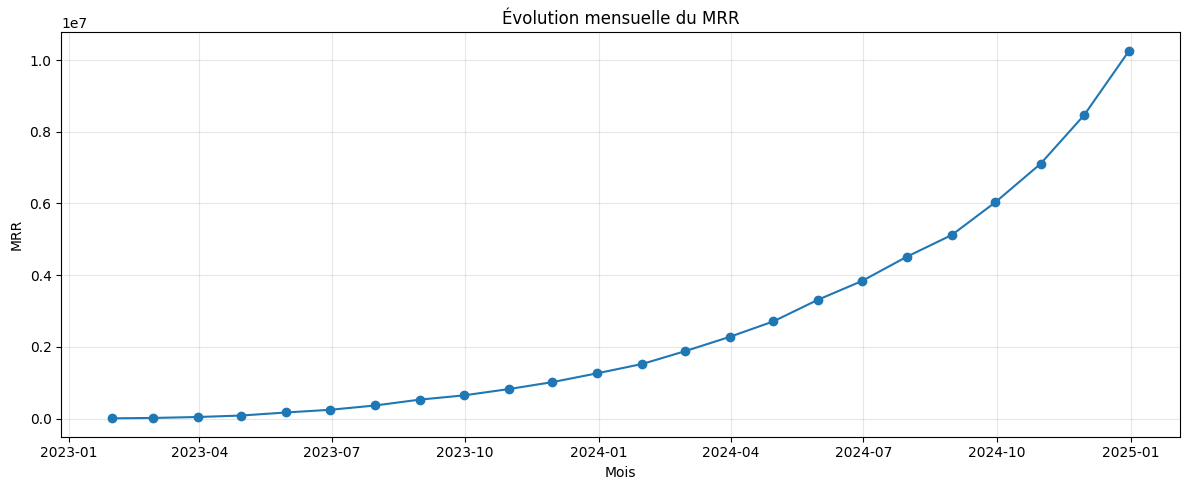

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    mrr_mensuel["mois"],
    mrr_mensuel["MRR"],
    marker="o"
)

plt.title("Évolution mensuelle du MRR")
plt.xlabel("Mois")
plt.ylabel("MRR")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Première lecture

Le MRR augmente fortement sur la période. Pour comprendre cette hausse, je sépare ensuite le MRR apporté par les abonnements qui commencent du MRR perdu lors des résiliations.


### 2.2 Nouveau MRR et MRR churné

Je calcule :

- `Nouveau MRR` : MRR des abonnements qui commencent pendant le mois
- `MRR churné` : MRR des abonnements qui se terminent avec `churn_flag = True`
- `MRR net simplifié` : Nouveau MRR - MRR churné

Le dernier indicateur est volontairement simplifié. Un vrai Net New MRR inclurait aussi l'expansion et la contraction liées aux upgrades et downgrades. Le dataset ne fournit pas un historique assez propre pour chiffrer ces mouvements de façon fiable.


In [17]:
# Mois de début de chaque abonnement
abonnements["mois_debut"] = abonnements["start_date"].dt.to_period("M")

# Nouveau MRR : somme du MRR des abonnements qui commencent chaque mois
abonnements_par_mois = abonnements.groupby("mois_debut")
nouveau_mrr = abonnements_par_mois["mrr_amount"].sum()

In [18]:
# On sélectionne uniquement les abonnements qui ont churné
abonnements_churnes = abonnements[
    abonnements["churn_flag"] == True
].copy()

# Mois de fin de ces abonnements
abonnements_churnes["mois_fin"] = (
    abonnements_churnes["end_date"].dt.to_period("M")
)

# MRR perdu chaque mois à cause du churn
churn_par_mois = abonnements_churnes.groupby("mois_fin")
mrr_churne = churn_par_mois["mrr_amount"].sum()


In [19]:
# On rassemble le nouveau MRR et le MRR churné dans un même tableau
evolution_mrr = pd.concat(
    [nouveau_mrr, mrr_churne],
    axis=1
)

evolution_mrr.columns = [
    "Nouveau MRR",
    "MRR churné"
]

# Les mois sans nouveau MRR ou sans churn sont remplacés par 0
evolution_mrr = evolution_mrr.fillna(0)

# MRR net simplifié simplifiée
evolution_mrr["MRR net simplifié"] = (
    evolution_mrr["Nouveau MRR"]
    - evolution_mrr["MRR churné"]
)

evolution_mrr


,Nouveau MRR,MRR churné,MRR net simplifié
2023-01,4684,0.0,4684.0
2023-02,11079,0.0,11079.0
2023-03,25885,0.0,25885.0
2023-04,41788,245.0,41543.0
2023-05,85919,0.0,85919.0
2023-06,74987,1176.0,73811.0
2023-07,120422,228.0,120194.0
2023-08,165621,686.0,164935.0
2023-09,116222,0.0,116222.0
2023-10,182518,5502.0,177016.0


### 2.3 Tableau récapitulatif

Le tableau suivant regroupe le MRR total, le nouveau MRR, le MRR churné et le MRR net simplifié.


In [20]:
# On transforme la date de fin de mois en période mensuelle
mrr_mensuel["mois_periode"] = mrr_mensuel["mois"].dt.to_period("M")

# Tableau du MRR total par mois
mrr_total = mrr_mensuel[
    ["mois_periode", "MRR"]
].copy()

mrr_total = mrr_total.set_index("mois_periode")

# Regroupement de tous les indicateurs dans un même tableau
tableau_revenu = mrr_total.join(evolution_mrr)

# Remplacement des éventuelles valeurs manquantes par 0
tableau_revenu = tableau_revenu.fillna(0)

# Arrondi pour améliorer la lisibilité
tableau_revenu = tableau_revenu.round(2)

tableau_revenu


,MRR,Nouveau MRR,MRR churné,MRR net simplifié
mois_periode,,,,
2023-01,4684,4684,0.0,4684.0
2023-02,15763,11079,0.0,11079.0
2023-03,41648,25885,0.0,25885.0
2023-04,83191,41788,245.0,41543.0
2023-05,169110,85919,0.0,85919.0
2023-06,242921,74987,1176.0,73811.0
2023-07,363115,120422,228.0,120194.0
2023-08,528050,165621,686.0,164935.0
2023-09,644272,116222,0.0,116222.0


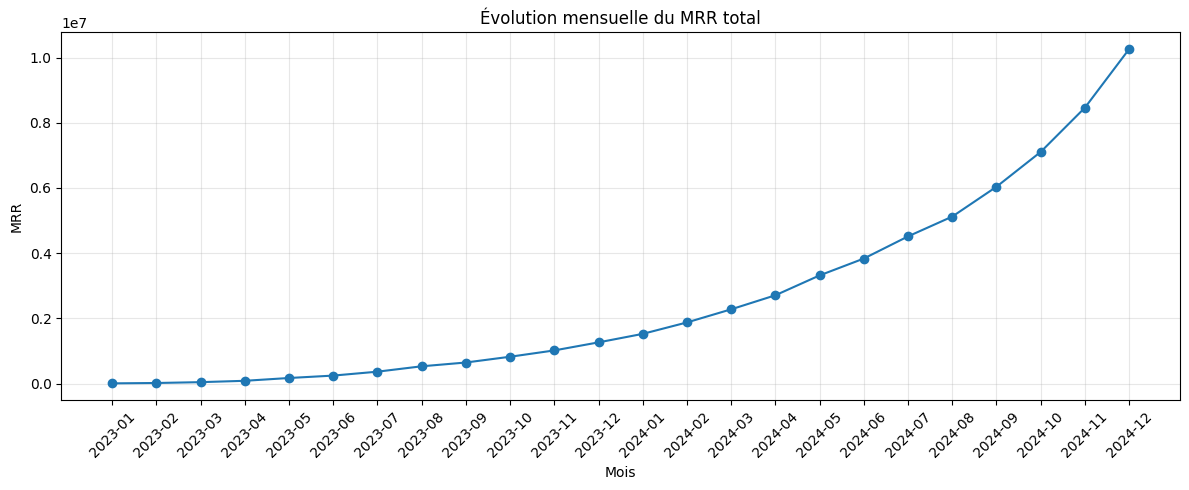

In [21]:
# Graphique 1 : évolution du MRR total
plt.figure(figsize=(12, 5))

plt.plot(
    tableau_revenu.index.astype(str),
    tableau_revenu["MRR"],
    marker="o"
)

plt.title("Évolution mensuelle du MRR total")
plt.xlabel("Mois")
plt.ylabel("MRR")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


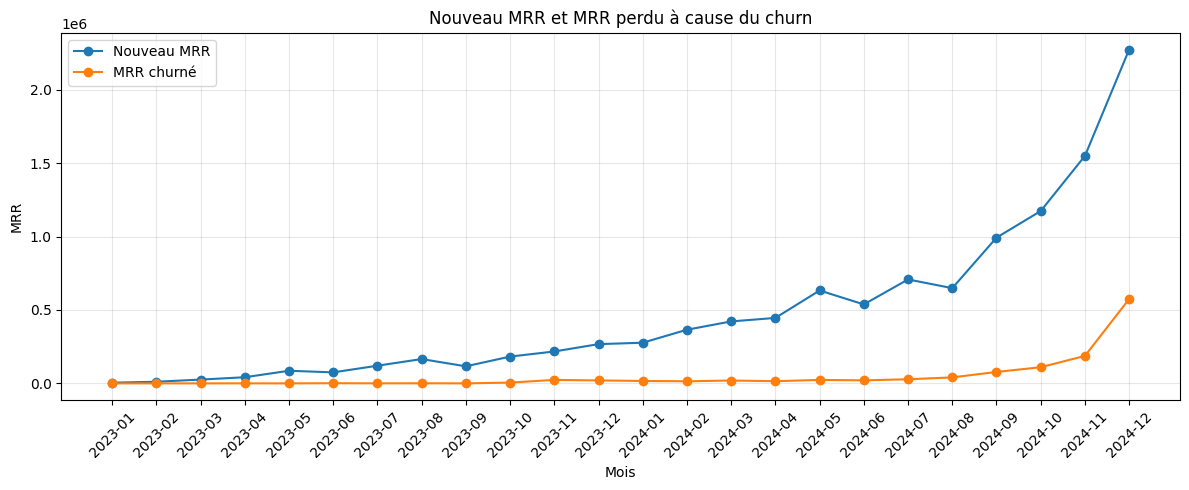

In [22]:
# Graphique 2 : comparaison du nouveau MRR et du MRR perdu par churn
plt.figure(figsize=(12, 5))

plt.plot(
    tableau_revenu.index.astype(str),
    tableau_revenu["Nouveau MRR"],
    marker="o",
    label="Nouveau MRR"
)

plt.plot(
    tableau_revenu.index.astype(str),
    tableau_revenu["MRR churné"],
    marker="o",
    label="MRR churné"
)

plt.title("Nouveau MRR et MRR perdu à cause du churn")
plt.xlabel("Mois")
plt.ylabel("MRR")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


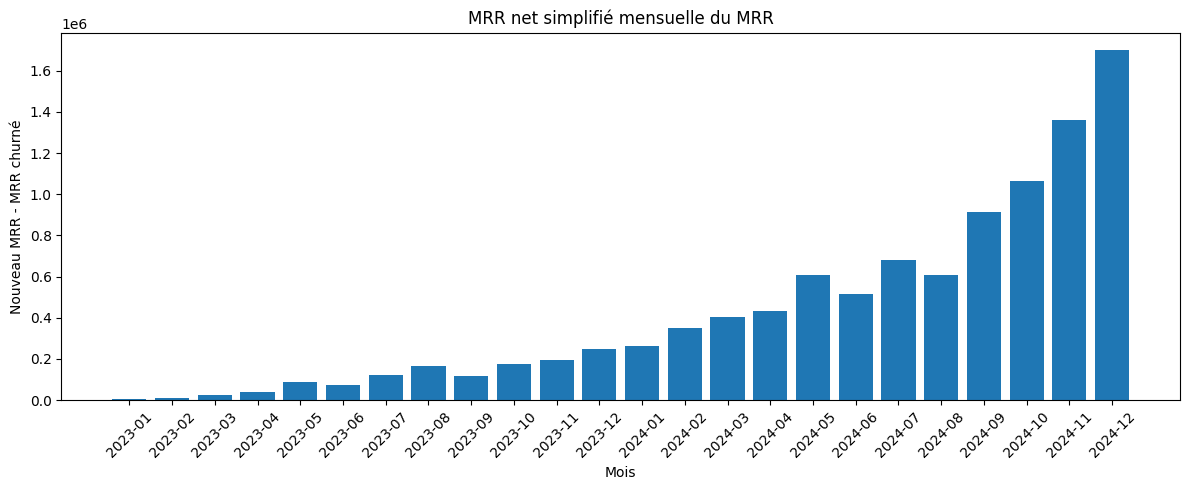

In [23]:
# Graphique 3 : évolution nette simplifiée du MRR
plt.figure(figsize=(12, 5))

plt.bar(
    tableau_revenu.index.astype(str),
    tableau_revenu["MRR net simplifié"]
)

plt.title("MRR net simplifié mensuelle du MRR")
plt.xlabel("Mois")
plt.ylabel("Nouveau MRR - MRR churné")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interprétation

Le MRR passe d'environ 4,7 k en janvier 2023 à 10,3 M en décembre 2024. Sur toute la période, le nouveau MRR reste supérieur au MRR churné, ce qui explique la croissance continue du revenu récurrent.

Décembre 2024 est aussi le mois où le MRR churné est le plus élevé. La croissance reste positive, mais la hausse des pertes mérite d'être suivie en parallèle de l'acquisition.


## 3. Analyse du churn

### 3.1 Taux de churn mensuel

Je définis le taux comme :

`comptes churnés pendant le mois / comptes actifs au début du mois`

Les réactivations sont exclues. Pour rester cohérent avec ce dénominateur, je ne compte au numérateur que les comptes qui étaient effectivement actifs au début du mois.


In [24]:
# Conversion de la date de churn en format date
churn["churn_date"] = pd.to_datetime(churn["churn_date"])

# Création du mois associé à chaque événement de churn
churn["mois_churn"] = churn["churn_date"].dt.to_period("M")

# On exclut les réactivations car elles ne correspondent pas à un départ client
churn_reel = churn[
    churn["is_reactivation"] == False
].copy()

# Nombre de comptes différents ayant churné chaque mois
churn_par_mois = churn_reel.groupby("mois_churn")["account_id"].nunique()

churn_par_mois.head()


mois_churn
2023-01    1
2023-03    5
2023-04    3
2023-05    3
2023-06    5
Freq: M, Name: account_id, dtype: int64

In [25]:
resultats_churn = []

for fin_mois in mois:
    debut_mois = fin_mois.to_period("M").to_timestamp()
    periode = debut_mois.to_period("M")

    actifs = abonnements[
        (abonnements["start_date"] <= debut_mois)
        & (
            abonnements["end_date"].isna()
            | (abonnements["end_date"] >= debut_mois)
        )
    ]

    comptes_actifs = set(actifs["account_id"])
    churn_du_mois = set(
        churn_reel.loc[
            churn_reel["mois_churn"] == periode,
            "account_id"
        ]
    )

    # Le numérateur doit appartenir à la population à risque au début du mois
    comptes_churnes = churn_du_mois.intersection(comptes_actifs)

    nb_actifs = len(comptes_actifs)
    nb_churnes = len(comptes_churnes)
    taux = nb_churnes / nb_actifs if nb_actifs else np.nan

    resultats_churn.append({
        "mois": periode,
        "comptes_actifs_debut": nb_actifs,
        "comptes_churnes": nb_churnes,
        "taux_churn_pct": taux * 100 if pd.notna(taux) else np.nan
    })

churn_mensuel = pd.DataFrame(resultats_churn)
churn_mensuel


,mois,comptes_actifs_debut,comptes_churnes,taux_churn_pct
0,2023-01,0,0,NaN
1,2023-02,2,0,0.000000
2,2023-03,10,1,10.000000
3,2023-04,21,1,4.761905
4,2023-05,37,3,8.108108
5,2023-06,50,4,8.000000
6,2023-07,71,2,2.816901
7,2023-08,90,6,6.666667
8,2023-09,117,4,3.418803
9,2023-10,131,4,3.053435


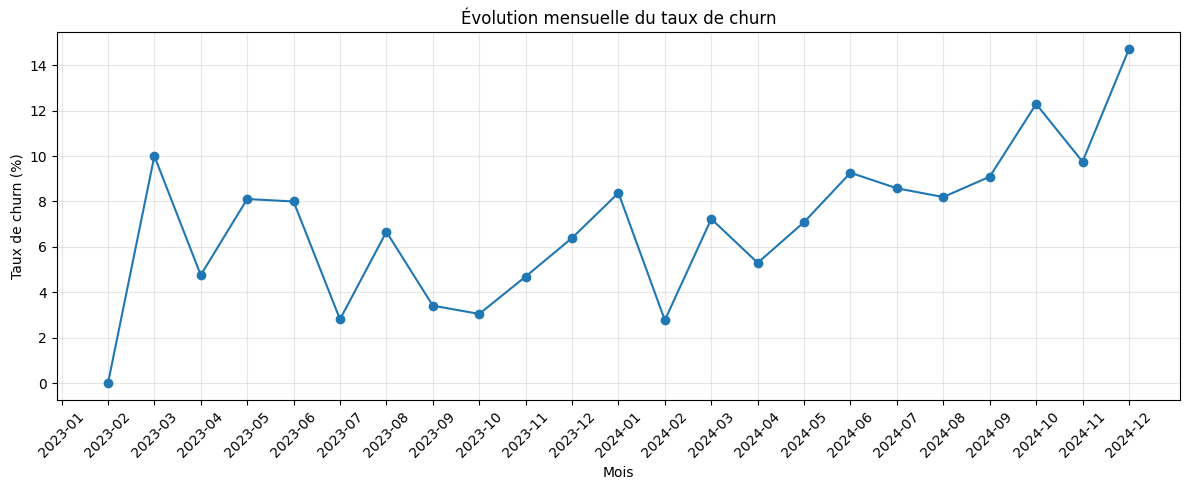

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    churn_mensuel["mois"].astype(str),
    churn_mensuel["taux_churn_pct"],
    marker="o"
)

plt.title("Évolution mensuelle du taux de churn")
plt.xlabel("Mois")
plt.ylabel("Taux de churn (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Lecture du churn mensuel

Le début de période reste volatil car il y a peu de comptes actifs. À partir de 2024, la base devient plus importante et le taux est plus lisible.

Le dataset contient aussi des événements de churn qui ne correspondent pas à un compte actif au début du mois. Ils sont exclus de ce calcul pour garder une définition cohérente du taux.


### 3.2 Churn par segment

Je compare ensuite le churn selon le plan, le secteur et le canal d'acquisition. Ici j'utilise `accounts.churn_flag`, donc il s'agit d'une vue transversale du statut des comptes, différente du calcul mensuel précédent.


In [27]:
# ----- Churn par plan -----

# Nombre total de comptes dans chaque plan
comptes_par_plan = comptes.groupby("plan_tier")["account_id"].nunique()

# Nombre de comptes churnés dans chaque plan
churn_par_plan = comptes[
    comptes["churn_flag"] == True
].groupby("plan_tier")["account_id"].nunique()

# Tableau récapitulatif
tableau_plan = pd.DataFrame({
    "Nombre de comptes": comptes_par_plan,
    "Comptes churnés": churn_par_plan
}).fillna(0)

# Calcul du taux de churn
tableau_plan["Taux de churn (%)"] = (
    tableau_plan["Comptes churnés"]
    / tableau_plan["Nombre de comptes"]
    * 100
)

tableau_plan = tableau_plan.sort_values("Taux de churn (%)", ascending=False)

tableau_plan.round(2)


,Nombre de comptes,Comptes churnés,Taux de churn (%)
plan_tier,,,
Enterprise,154,34,22.08
Basic,168,37,22.02
Pro,178,39,21.91


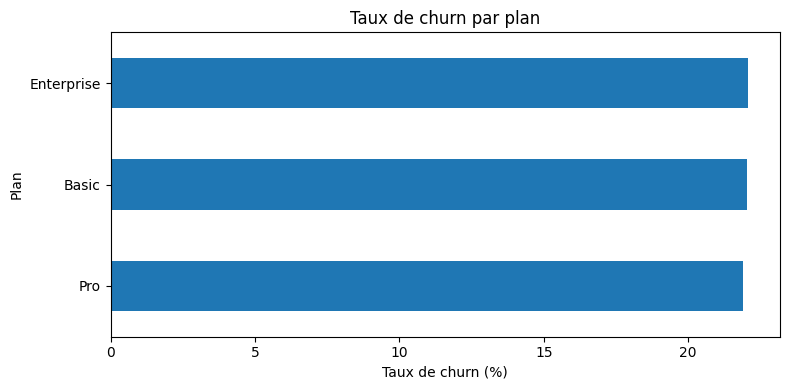

In [28]:
plt.figure(figsize=(8, 4))

tableau_plan["Taux de churn (%)"].sort_values().plot(kind="barh")

plt.title("Taux de churn par plan")
plt.xlabel("Taux de churn (%)")
plt.ylabel("Plan")
plt.tight_layout()
plt.show()


Observation plan : les trois plans sont presque au même niveau, autour de 22 %. Le plan ne semble donc pas être un facteur très discriminant dans ce dataset.


In [29]:
# ----- Churn par secteur -----

# Nombre total de comptes dans chaque secteur
comptes_par_secteur = comptes.groupby("industry")["account_id"].nunique()

# Nombre de comptes churnés dans chaque secteur
churn_par_secteur = comptes[
    comptes["churn_flag"] == True
].groupby("industry")["account_id"].nunique()

# Tableau récapitulatif
tableau_secteur = pd.DataFrame({
    "Nombre de comptes": comptes_par_secteur,
    "Comptes churnés": churn_par_secteur
}).fillna(0)

# Calcul du taux de churn
tableau_secteur["Taux de churn (%)"] = (
    tableau_secteur["Comptes churnés"]
    / tableau_secteur["Nombre de comptes"]
    * 100
)

tableau_secteur = tableau_secteur.sort_values("Taux de churn (%)", ascending=False)

tableau_secteur.round(2)


,Nombre de comptes,Comptes churnés,Taux de churn (%)
industry,,,
DevTools,113,35,30.97
FinTech,112,25,22.32
HealthTech,96,21,21.88
EdTech,79,13,16.46
Cybersecurity,100,16,16.00


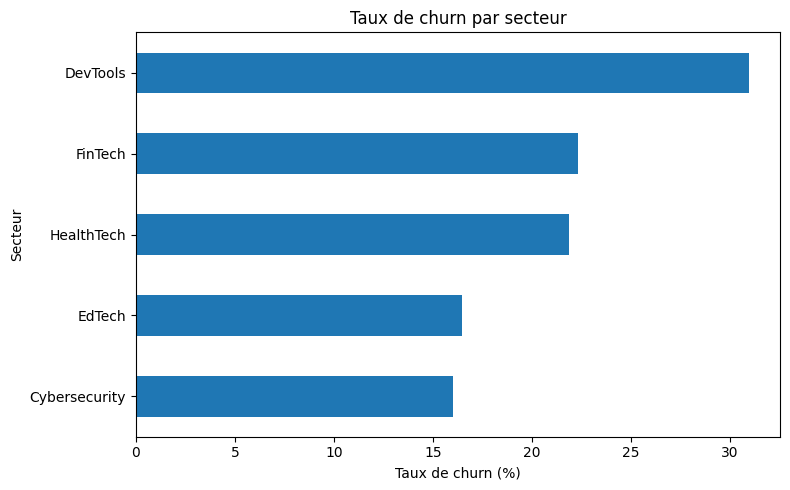

In [30]:
plt.figure(figsize=(8, 5))

tableau_secteur["Taux de churn (%)"].sort_values().plot(kind="barh")

plt.title("Taux de churn par secteur")
plt.xlabel("Taux de churn (%)")
plt.ylabel("Secteur")
plt.tight_layout()
plt.show()


Observation secteur : DevTools a le churn le plus élevé, autour de 31 % (35 comptes sur 113). EdTech et Cybersecurity sont autour de 16 %. Le secteur semble davantage différencier le churn que le plan.


In [31]:
# ----- Churn par canal d'acquisition -----

# Nombre total de comptes provenant de chaque canal
comptes_par_canal = comptes.groupby("referral_source")["account_id"].nunique()

# Nombre de comptes churnés provenant de chaque canal
churn_par_canal = comptes[
    comptes["churn_flag"] == True
].groupby("referral_source")["account_id"].nunique()

# Tableau récapitulatif
tableau_canal = pd.DataFrame({
    "Nombre de comptes": comptes_par_canal,
    "Comptes churnés": churn_par_canal
}).fillna(0)

# Calcul du taux de churn
tableau_canal["Taux de churn (%)"] = (
    tableau_canal["Comptes churnés"]
    / tableau_canal["Nombre de comptes"]
    * 100
)

tableau_canal = tableau_canal.sort_values("Taux de churn (%)", ascending=False)

tableau_canal.round(2)


,Nombre de comptes,Comptes churnés,Taux de churn (%)
referral_source,,,
event,96,29,30.21
other,103,25,24.27
ads,98,23,23.47
organic,114,20,17.54
partner,89,13,14.61


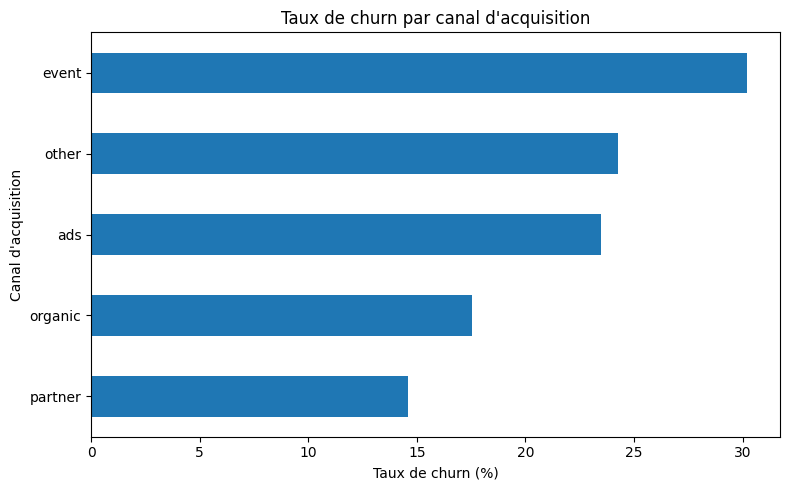

In [32]:
plt.figure(figsize=(8, 5))

tableau_canal["Taux de churn (%)"].sort_values().plot(kind="barh")

plt.title("Taux de churn par canal d'acquisition")
plt.xlabel("Taux de churn (%)")
plt.ylabel("Canal d'acquisition")
plt.tight_layout()
plt.show()


Observation acquisition : les comptes provenant d'événements ont le churn le plus élevé, autour de 30 %. Les partenaires sont les plus bas, autour de 15 %, puis l'organique autour de 18 %.

Une explication possible est que les canaux n'apportent pas des clients avec le même niveau d'intention ou de qualification.


### 3.3 Hypothèses business

Les résultats montrent des associations, pas des causes. Trois pistes à tester seraient :

1. Les événements peuvent générer davantage de prospects peu qualifiés, alors que les partenaires préqualifient mieux les besoins.
2. Les clients DevTools peuvent avoir des attentes plus fortes sur les intégrations, les performances ou certaines fonctionnalités.
3. Comme les plans ont des taux proches, le churn semble davantage lié au profil du client, à son acquisition ou à son expérience produit qu'au niveau de forfait seul.


### Bilan churn

Les écarts les plus visibles concernent le secteur DevTools et le canal `event`. À l'inverse, les plans sont très proches. Ce sont des signaux à investiguer, pas des preuves de causalité.


## 4. Analyse de l'usage produit

### 4.1 Usage et churn

Comme les dates d'usage sont peu fiables, je compare l'usage de manière agrégée par compte.

Je regarde surtout le volume d'usage par abonnement, la durée, le taux d'erreur, le nombre de jours actifs et le nombre de fonctionnalités utilisées.


In [33]:
usage_comptes = usage.merge(
    abonnements[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left"
)
# On relie les données d'usage aux comptes via les abonnements

In [34]:
usage_par_compte = usage_comptes.groupby("account_id").agg(
    total_usage=("usage_count", "sum"),
    duree_totale=("usage_duration_secs", "sum"),
    total_erreurs=("error_count", "sum"),
    jours_actifs=("usage_date", "nunique"),
    fonctionnalites_utilisees=("feature_name", "nunique")
).reset_index()
# On regroupe l'usage par compte pour obtenir des indicateurs globaux

In [35]:
nb_abonnements = (
    abonnements.groupby("account_id")["subscription_id"]
    .nunique()
    .reset_index(name="nb_abonnements")
)

usage_par_compte = usage_par_compte.merge(
    nb_abonnements,
    on="account_id",
    how="left"
)
# On calcule le nombre d'abonnements associés à chaque compte

In [36]:
usage_par_compte = usage_par_compte.merge(
    comptes[["account_id", "churn_flag"]],
    on="account_id",
    how="left"
)
# On ajoute l'information de churn à chaque compte

In [37]:
usage_par_compte["usage_par_abonnement"] = (
    usage_par_compte["total_usage"] / usage_par_compte["nb_abonnements"]
)

usage_par_compte["duree_par_abonnement"] = (
    usage_par_compte["duree_totale"] / usage_par_compte["nb_abonnements"]
)

usage_par_compte["erreurs_par_100_usages"] = (
    usage_par_compte["total_erreurs"] / usage_par_compte["total_usage"] * 100
)
# On normalise les indicateurs d'usage pour pouvoir comparer les comptes

In [39]:
comparaison_usage = usage_par_compte.groupby(
    "churn_flag"
)[
    [
        "usage_par_abonnement",
        "duree_par_abonnement",
        "erreurs_par_100_usages",
        "jours_actifs",
        "fonctionnalites_utilisees"
    ]
].median()
# On compare les indicateurs d'usage médians entre comptes churnés et conservés
comparaison_usage

,usage_par_abonnement,duree_par_abonnement,erreurs_par_100_usages,jours_actifs,fonctionnalites_utilisees
churn_flag,,,,,
False,49.690476,15282.925000,5.498052,48.0,28.0
True,51.104167,15162.241667,5.369897,51.0,29.0


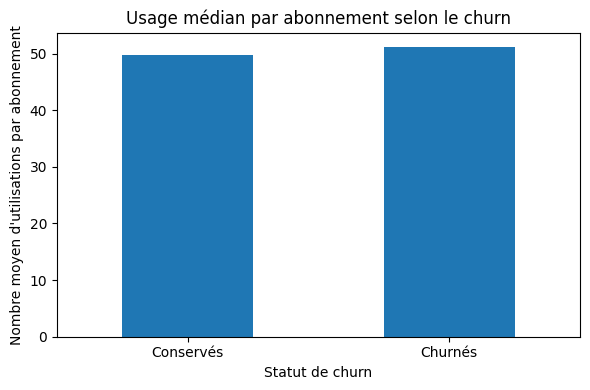

In [40]:
plt.figure(figsize=(6, 4))

comparaison_usage["usage_par_abonnement"].plot(
    kind="bar"
)

plt.title("Usage médian par abonnement selon le churn")
plt.xlabel("Statut de churn")
plt.ylabel("Nombre moyen d'utilisations par abonnement")
plt.xticks(
    [0, 1],
    ["Conservés", "Churnés"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Interprétation

Les deux groupes sont très proches. Les comptes churnés ont même un usage médian par abonnement légèrement supérieur, tandis que la durée d'utilisation et le taux d'erreur sont presque identiques.

Je ne vois donc pas de lien fort entre l'intensité globale d'usage et le churn. Avec des dates plus fiables, je regarderais plutôt l'évolution de l'usage dans les 30 ou 60 jours avant le churn.


### 4.2 Fonctionnalités les plus utilisées

Pour éviter qu'un groupe plus nombreux domine seulement par son volume, j'agrège d'abord l'usage par compte et par fonctionnalité, puis je compare la moyenne entre comptes.


In [41]:
# On regroupe l'usage par compte et par fonctionnalité
usage_fonctions = usage_comptes.groupby(
    ["account_id", "feature_name"]
)["usage_count"].sum().reset_index()

# On ajoute le statut churn du compte
usage_fonctions = usage_fonctions.merge(
    comptes[["account_id", "churn_flag"]],
    on="account_id",
    how="left"
)

# Usage moyen par fonctionnalité selon le statut de churn
comparaison_fonctions = usage_fonctions.groupby(
    ["churn_flag", "feature_name"]
)["usage_count"].mean().reset_index()

In [42]:
# Top 5 des comptes conservés
top_conserves = comparaison_fonctions[
    comparaison_fonctions["churn_flag"] == False
].sort_values(
    "usage_count",
    ascending=False
).head(5)

top_conserves

,churn_flag,feature_name,usage_count
14,False,feature_22,19.335938
25,False,feature_32,19.300366
36,False,feature_6,19.189591
12,False,feature_20,19.077821
1,False,feature_10,19.070039


In [43]:
# Top 5 des comptes churnés
top_churnes = comparaison_fonctions[
    comparaison_fonctions["churn_flag"] == True
].sort_values(
    "usage_count",
    ascending=False
).head(5)

top_churnes

,churn_flag,feature_name,usage_count
67,True,feature_34,21.355263
52,True,feature_20,21.272727
40,True,feature_1,20.962025
46,True,feature_15,20.670732
42,True,feature_11,20.400000


### Interprétation

Chez les comptes conservés, les fonctionnalités les plus utilisées sont `feature_22`, `feature_32`, `feature_6`, `feature_20` et `feature_10`.

Chez les comptes churnés, ce sont `feature_34`, `feature_20`, `feature_1`, `feature_15` et `feature_11`.

`feature_20` apparaît dans les deux groupes. Comme les fonctionnalités sont anonymisées et que les niveaux d'usage sont proches, je n'en déduis pas de cause métier précise.


## 5. Recommandations

### 5.1 KPIs pour un dashboard SaaS

Je garderais cinq indicateurs :

1. MRR total, pour suivre la taille du revenu récurrent
2. Nouveau MRR et MRR churné, pour comprendre d'où vient la variation
3. Taux de churn client, avec filtres par secteur, canal et plan
4. Revenue churn, pour mesurer le poids financier des clients perdus
5. Engagement produit, par exemple jours actifs et nombre de fonctionnalités utilisées par compte


### 5.2 Amélioration du modèle de données

Je créerais une table mensuelle avec une ligne par abonnement et par mois. Elle contiendrait au minimum le compte, le plan, le MRR, le statut actif, un indicateur de nouvel abonnement et un indicateur de churn.

Cela éviterait de reconstruire les périodes actives à chaque analyse et rendrait les calculs de MRR et de churn plus simples à contrôler.


Exemple :

| mois | subscription_id | account_id | plan | actif | MRR | nouveau | churn |
|---|---|---|---|---|---|---|---|
| 2024-01 | S-001 | A-001 | Basic | True | 120 | True | False |
| 2024-02 | S-001 | A-001 | Basic | True | 120 | False | False |
| 2024-03 | S-001 | A-001 | Basic | False | 0 | False | True |


### 5.3 Amélioration du pipeline

Je mettrais en place quelques contrôles automatiques avant l'alimentation du dashboard : unicité des identifiants, clés étrangères valides, cohérence des dates, valeurs négatives ou impossibles et cohérence entre les différents indicateurs de churn.

C'est particulièrement utile ici à cause des doublons de `usage_id` et des incohérences de dates dans la table d'usage.


## Résumé des conclusions

- Le MRR augmente fortement sur la période et le nouveau MRR reste supérieur au MRR churné.
- Le churn varie davantage selon le secteur et le canal d'acquisition que selon le plan. DevTools et le canal `event` ressortent comme les segments à surveiller.
- L'usage global est très proche entre comptes churnés et conservés. Je ne vois pas de signal fort à ce niveau.
- Les principales limites viennent de la cohérence temporelle de `feature_usage` et des différentes définitions du churn dans les tables.

Pour aller plus loin, je commencerais par fiabiliser le modèle de données puis j'ajouterais une analyse de cohortes et un modèle simple de prédiction du churn.
